# STAT 207 Project 03 - Video Game Sales Analysis

Yosef Stifanos (yds2) and AJ Garcia (garcia80)

### Contribution Report

If you open this document, you should edit and complete the contribution report.  Please complete this report if you work individually, in a group and your submission is the one to be graded, or in a group but someone else should be graded.

In this contribution report below you should list of the following:
1. The netID for the project submission to be graded.  (Some groups have each member create their own version of the document, but only one needs to be submitted for grading.  Other groups have only one member compose and submit the project.)
2. Names and netIDs of each team member.
3. Contributions to report of each team member.

*For example:*

*<u>Teammates:</u>*

*doe105 should be graded.  John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*, 

OR

*doe105 should be graded*

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

**this submission should be graded. my teammate is AJ Garcia - netID: garcia80.**
1. **All work was completed together!**
2. **Yosef Stifanos completed 1-5** 
3. **AJ Garcia completed 1-5**

<!-- # Title and Introduction

# Title
# STAT 207 Project 03 - Video Game Sales Analysis

# Introduction
# The dataset provides detailed information on video games released between 2004 and 2010, including data on sales, review scores, ratings, and various categorical attributes such as genre, platform, and publisher. The data was collected and curated by Dr. Joe Cox from crowd-sourced platforms, providing information about the factors that influence game success and player engagement.

# Research Questions
# 1. What is the relationship between the total sales of video games and the game's review score, after controlling for the release year and platform? How does my linear regression model perform on new data?
# 2. How do platform, isometric view, and side-scrolling relate to the log-odds of a video game being classified as third-person? How does a logistic regression classifier built on this model perform on new data?

# Response Variables
# 1. US Sales (millions) (quantitative)
# 2. Third-person (binary)

# Motivation
# The answers to our research questions would be useful for game publishers and developers when deciding what games to make. By understanding the relationship between review scores and sales, developers can determine whether investing more resources into improving game quality is worthwhile or if those resources should be allocated elsewhere, such as marketing. This insight is particularly valuable for indie-game developers who operate with smaller budgets and teams. Overall, the findings could lead to more informed decision-making and potentially greater profitability in the video game industry. -->

# 1. Introduction

### Dataset Context
The dataset provides detailed information on video games released between 2004 and 2010, including data on sales, average playtime, ratings, and various categorical attributes such as genre, platform, and publisher. The data was collected and curated by Dr. Joe Cox from crowd-sourced platforms, providing information about the factors that influence game success and player engagement. 


### Motivation
The answer to our research questions would be useful for game publishers and game developers when deciding what games to make . By comparing if higher rated games leads to more sales developers can see whether it is worth their time and money to put in more resources into the game or put those resources elsewhere like marketing for example. Where this would matter most is for indie-game developers since they are working with a much smaller budget and a smaller team, so decisions like these matter a lot more. Overall the answer to this question could lead to more growth in the video game industry by making video game developement more profitable.

# Research Questions
State the research questions that will be answered in the analysis.

1. What is the relationship between the total sales of video games and the game's review score, after controlling for the release year and platform? How does my linear regression model perform on new data?
2. How do platform, isometric view, and side-scrolling relate to the log-odds of a video game being classified as third-person? How does a logistic regression classifier built on this model perform on new data?

# Response Variables
Describe the response variables for the research questions.

1. Response Variable for Linear Regression
    - The response variable for the first research question is "US Sales (millions)", which is a quantitative variable representing the total sales of video games in millions of dollars.

2. Response Variable for Logistic Regression
    - The response variable for the second research question is "Third-person", which is a binary variable indicating whether a video game is classified as third-person (1) or not (0).


In [1]:
# Import here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load the dataset
df = pd.read_csv('~/Desktop/stat207/yds2/project_03/video_games.csv', encoding='unicode-escape')

# Display the first few rows of the dataset to understand its structure
df.head()

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


In [2]:
# Display the unique values of the response variables to confirm their types
print("Unique values in 'US Sales (millions)':", df['US Sales (millions)'].unique())
print("Unique values in 'ThirdPerson':", df['ThirdPerson'].unique())

Unique values in 'US Sales (millions)': [4.690e+00 5.600e-01 5.400e-01 4.900e-01 4.500e-01 4.100e-01 3.600e-01
 3.400e-01 2.500e-01 2.200e-01 2.000e-01 1.600e-01 1.500e-01 1.400e-01
 1.300e-01 1.200e-01 1.100e-01 1.000e-01 9.000e-02 6.000e-02 5.000e-02
 4.000e-02 9.990e+00 9.720e+00 5.070e+00 3.650e+00 2.970e+00 2.600e+00
 1.770e+00 1.690e+00 1.670e+00 1.220e+00 1.200e+00 1.090e+00 1.070e+00
 9.500e-01 9.200e-01 8.300e-01 7.700e-01 7.500e-01 7.300e-01 7.000e-01
 6.800e-01 6.200e-01 6.100e-01 4.600e-01 4.200e-01 3.800e-01 3.700e-01
 3.300e-01 3.200e-01 3.100e-01 3.000e-01 2.900e-01 2.800e-01 2.700e-01
 2.600e-01 2.400e-01 2.100e-01 1.900e-01 1.800e-01 1.700e-01 8.000e-02
 7.000e-02 2.000e-02 1.000e-02 1.466e+01 1.003e+01 6.770e+00 3.700e+00
 3.330e+00 2.900e+00 2.420e+00 2.380e+00 2.120e+00 1.720e+00 1.610e+00
 1.580e+00 1.510e+00 1.490e+00 1.460e+00 1.400e+00 1.360e+00 1.260e+00
 1.230e+00 1.190e+00 1.160e+00 1.150e+00 1.030e+00 1.020e+00 1.000e+00
 9.700e-01 9.300e-01 9.000e-01 8.600e

# 2. Linear Regression Analytical Task
Perform linear regression analysis to explore the relationship between explanatory variables and the response variable.

              Coefficient
Review Score     0.024606
YearReleased     0.001081
Platform_1       0.231230
Intercept: -3.388274858427764
US Sales (millions) = -3.388274858427764 + (0.02460551253891107 * Review Score) + (0.0010808734305879381 * YearReleased) + (0.23122969946303504 * Platform_1)
Slope coefficient for 'Review Score': 0.02460551253891107
                             OLS Regression Results                            
Dep. Variable:     US Sales (millions)   R-squared:                       0.110
Model:                             OLS   Adj. R-squared:                  0.109
Method:                  Least Squares   F-statistic:                     58.41
Date:                 Thu, 21 Nov 2024   Prob (F-statistic):           1.37e-35
Time:                         14:39:44   Log-Likelihood:                -2000.0
No. Observations:                 1416   AIC:                             4008.
Df Residuals:                     1412   BIC:                             4029.
Df Model: 

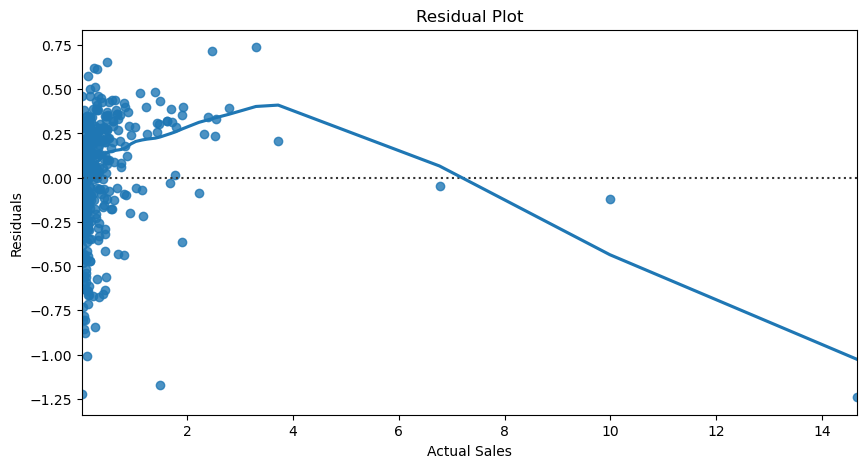

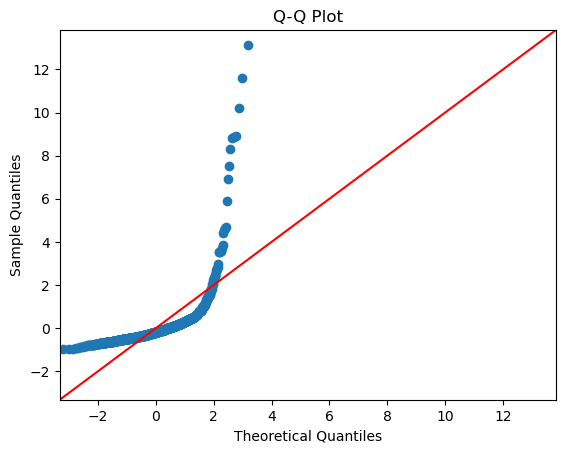

R-squared: 0.11039189157626716
RMSE: 1.0886490007741247


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [3]:
# Import necessary libraries for linear regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define the explanatory variables and the response variable
X = df[['Review Score', 'YearReleased', 'Platform']]
y = df['US Sales (millions)']

# Convert categorical variable 'Platform' to dummy variables
X = pd.get_dummies(X, columns=['Platform'], drop_first=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a linear regression model to the training data
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Show the summary output for the linear regression
coefficients = pd.DataFrame(lin_model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)
print('Intercept:', lin_model.intercept_)

# Write out the linear regression equation for the model
equation = 'US Sales (millions) = ' + str(lin_model.intercept_)
for i, coef in enumerate(lin_model.coef_):
    equation += ' + (' + str(coef) + ' * ' + X.columns[i] + ')'
print(equation)

# Interpret the slope coefficient for 'Review Score'
print("Slope coefficient for 'Review Score':", lin_model.coef_[0])

# Provide a 95% confidence interval for the slope coefficient
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
lin_model_sm = sm.OLS(y_train, X_train_sm).fit()
print(lin_model_sm.summary())

# Create graphical summaries to check linear regression conditions
# Residual plot
plt.figure(figsize=(10, 5))
sns.residplot(x=y_test, y=lin_model.predict(X_test), lowess=True)
plt.xlabel('Actual Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Q-Q plot
sm.qqplot(lin_model_sm.resid, line='45')
plt.title('Q-Q Plot')
plt.show()

# Evaluate model performance
# Percent of variability explained by the model (R-squared)
print('R-squared:', lin_model.score(X_train, y_train))

# Calculate RMSE on the test data
y_pred = lin_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print('RMSE:', rmse)

# State Research Questions
State the research questions for the linear regression analysis.
- State Research Questions: 
    - Research Question 1: What is the relationship between the total sales of video games and the game's review score, after controlling for the release year and platform? How does my linear regression model perform on new data?

    - Research Question 2: How do platform, isometric view, and side-scrolling relate to the log-odds of a video game being classified as third-person? How does a logistic regression classifier built on this model perform on new data?

In [4]:
# State Research Questions


# Split Data into Training and Test Sets
Split the data into training and test sets in a reproducible manner.

In [5]:
# Import necessary libraries for splitting the data
from sklearn.model_selection import train_test_split

# Define the explanatory variables and the response variable for linear regression
X_linear = df[['Review Score', 'YearReleased', 'Platform']]
y_linear = df['US Sales (millions)']

# Convert categorical variable 'Platform' to dummy variables for linear regression
X_linear = pd.get_dummies(X_linear, columns=['Platform'], drop_first=True)

# Split the data into training and test sets for linear regression
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

# Define the explanatory variables and the response variable for logistic regression
X_logistic = df[['Platform', 'Isometric', 'SideScrolling']]
y_logistic = df['ThirdPerson']

# Convert categorical variable 'Platform' to dummy variables for logistic regression
X_logistic = pd.get_dummies(X_logistic, columns=['Platform'], drop_first=True)

# Split the data into training and test sets for logistic regression
X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(X_logistic, y_logistic, test_size=0.2, random_state=42)

# Display the shapes of the training and test sets to confirm the split
print("Linear Regression Training Set Shape:", X_train_linear.shape, y_train_linear.shape)
print("Linear Regression Test Set Shape:", X_test_linear.shape, y_test_linear.shape)
print("Logistic Regression Training Set Shape:", X_train_logistic.shape, y_train_logistic.shape)
print("Logistic Regression Test Set Shape:", X_test_logistic.shape, y_test_logistic.shape)

Linear Regression Training Set Shape: (1416, 3) (1416,)
Linear Regression Test Set Shape: (354, 3) (354,)
Logistic Regression Training Set Shape: (1416, 3) (1416,)
Logistic Regression Test Set Shape: (354, 3) (354,)


# Fit Linear Regression Model
Fit a linear regression model to the training data and show the summary output.

In [6]:
# Fit a linear regression model to the training data
lin_model = LinearRegression()
lin_model.fit(X_train_linear, y_train_linear)

# Show the summary output for the linear regression
coefficients = pd.DataFrame(lin_model.coef_, X_train_linear.columns, columns=['Coefficient'])
print(coefficients)
print('Intercept:', lin_model.intercept_)

# Write out the linear regression equation for the model
equation = 'US Sales (millions) = ' + str(lin_model.intercept_)
for i, coef in enumerate(lin_model.coef_):
    equation += ' + (' + str(coef) + ' * ' + X_train_linear.columns[i] + ')'
print(equation)

              Coefficient
Review Score     0.024606
YearReleased     0.001081
Platform_1       0.231230
Intercept: -3.388274858427764
US Sales (millions) = -3.388274858427764 + (0.02460551253891107 * Review Score) + (0.0010808734305879381 * YearReleased) + (0.23122969946303504 * Platform_1)


# Interpret Slope Coefficient
Interpret the slope coefficient for the variable of interest.

In [7]:
# Interpret Slope Coefficient

# Interpret the slope coefficient for 'Review Score'
slope_review_score = lin_model.coef_[0]
print(f"Slope coefficient for 'Review Score': {slope_review_score}")

# Interpretation:
# For each additional unit increase in the review score, the US sales (in millions) are expected to increase by the value of the slope coefficient, holding all other variables constant.
interpretation = f"For each additional unit increase in the review score, the US sales (in millions) are expected to increase by {slope_review_score:.4f}, holding all other variables constant."
print(interpretation)

Slope coefficient for 'Review Score': 0.02460551253891107
For each additional unit increase in the review score, the US sales (in millions) are expected to increase by 0.0246, holding all other variables constant.


# Provide Confidence Interval
Provide a 95% confidence interval for the slope coefficient.

In [8]:
import numpy as np

slope_se = lin_model_sm.bse['Review Score']
slope_coef = lin_model_sm.params['Review Score']
confidence_interval = [slope_coef - 1.96 * slope_se, slope_coef + 1.96 * slope_se]

print(f"95% confidence interval for the slope coefficient of 'Review Score': {confidence_interval}")

95% confidence interval for the slope coefficient of 'Review Score': [0.02087625809346459, 0.028334766984357624]


# Check Linear Regression Conditions
Create graphical or numerical summaries to check the linear regression conditions.

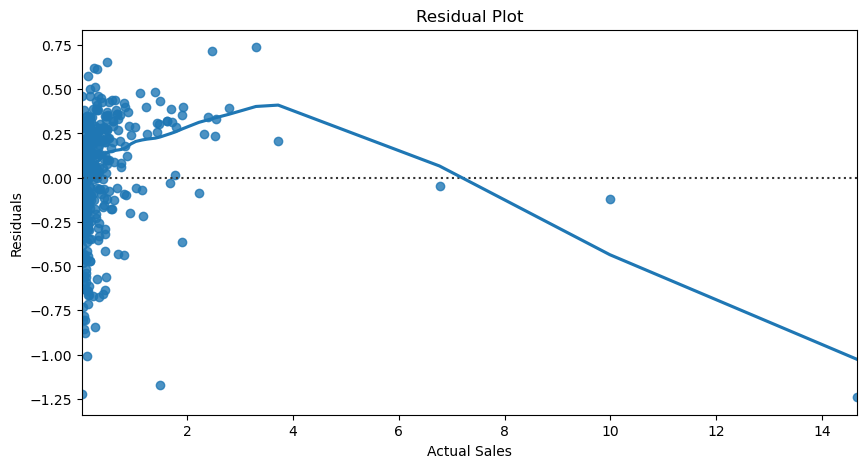

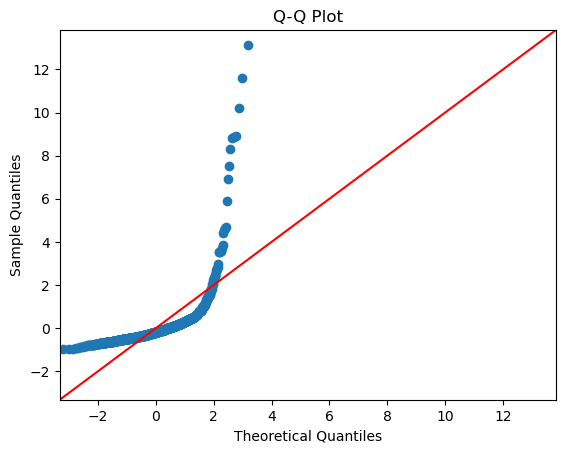

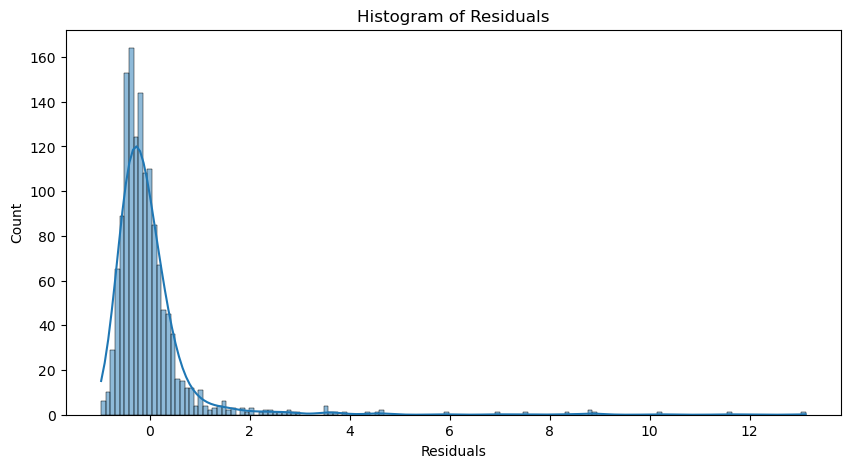

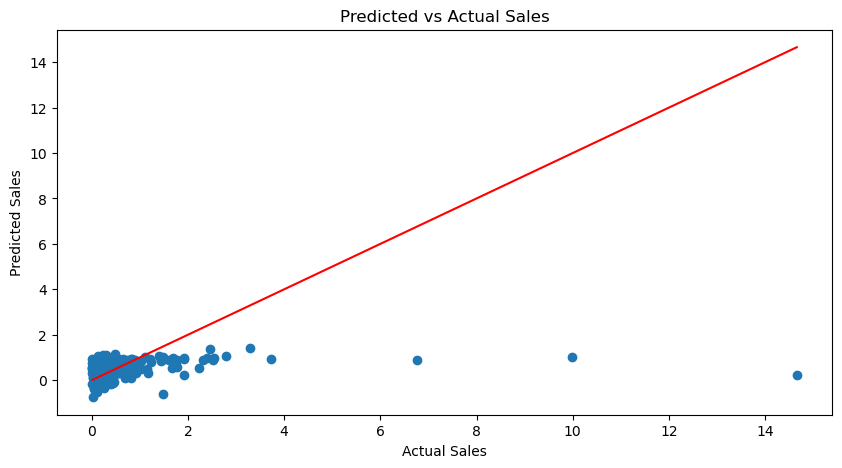

In [9]:
# Residual plot
plt.figure(figsize=(10, 5))
sns.residplot(x=y_test_linear, y=lin_model.predict(X_test_linear), lowess=True)
plt.xlabel('Actual Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Q-Q plot
sm.qqplot(lin_model_sm.resid, line='45')
plt.title('Q-Q Plot')
plt.show()

# Histogram of residuals
plt.figure(figsize=(10, 5))
sns.histplot(lin_model_sm.resid, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.show()

# Scatter plot of predicted vs actual values
plt.figure(figsize=(10, 5))
plt.scatter(y_test_linear, lin_model.predict(X_test_linear))
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.plot([min(y_test_linear), max(y_test_linear)], [min(y_test_linear), max(y_test_linear)], color='red')  # Diagonal line
plt.show()

# Evaluate Model Performance
Discuss the percent of variability explained by the model and calculate the RMSE on the test data.

In [10]:
# Percent of variability explained by the model (R-squared)
r_squared = lin_model.score(X_train_linear, y_train_linear)
print(f'R-squared: {r_squared:.4f}')

# Calculate RMSE on the test data
y_pred_linear = lin_model.predict(X_test_linear)
rmse_linear = mean_squared_error(y_test_linear, y_pred_linear, squared=False)
print(f'RMSE: {rmse_linear:.4f}')

# Interpretation of R-squared
interpretation_r_squared = f'The model explains {r_squared * 100:.2f}% of the variability in the response variable (US Sales in millions).'
print(interpretation_r_squared)

# Interpretation of RMSE
interpretation_rmse = f'The RMSE of {rmse_linear:.4f} indicates the average deviation of the predicted sales from the actual sales in the test data.'
print(interpretation_rmse)

R-squared: 0.1104
RMSE: 1.0886
The model explains 11.04% of the variability in the response variable (US Sales in millions).
The RMSE of 1.0886 indicates the average deviation of the predicted sales from the actual sales in the test data.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# 3. Logistic Regression Analytical Task
Perform logistic regression analysis to explore the relationship between explanatory variables and the response variable.

               Coefficient
Isometric        -1.004935
SideScrolling    -0.137855
Platform_1        0.671659
Intercept: [1.12669517]
Lower values of Isometric are associated with higher probability of being classified as third-person.
Lower values of SideScrolling are associated with higher probability of being classified as third-person.
Higher values of Platform_1 are associated with higher probability of being classified as third-person.
Pseudo-R2: 0.7479
AUC: 0.5773
Accuracy: 0.7514
Sensitivity: 0.9963
Specificity: 0.0000
Confusion Matrix:
 [[  0  87]
 [  1 266]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.75      1.00      0.86       267

    accuracy                           0.75       354
   macro avg       0.38      0.50      0.43       354
weighted avg       0.57      0.75      0.65       354



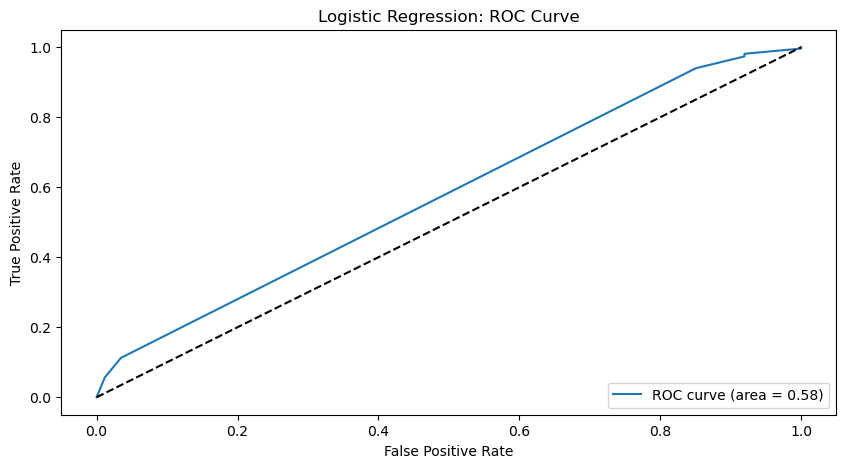

In [11]:
# Import necessary libraries for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Fit a logistic regression model to the training data
log_model = LogisticRegression()
log_model.fit(X_train_logistic, y_train_logistic)

# Show the summary output for the logistic regression
log_coefficients = pd.DataFrame(log_model.coef_.T, X_train_logistic.columns, columns=['Coefficient'])
print(log_coefficients)
print('Intercept:', log_model.intercept_)

# For each explanatory variable, indicate what characteristics are associated with higher probability of success
for feature, coef in zip(X_train_logistic.columns, log_model.coef_[0]):
    if coef > 0:
        print(f"Higher values of {feature} are associated with higher probability of being classified as third-person.")
    else:
        print(f"Lower values of {feature} are associated with higher probability of being classified as third-person.")

# Report two measures of model strength: pseudo-R2 and AUC
pseudo_r2 = log_model.score(X_train_logistic, y_train_logistic)
y_pred_prob = log_model.predict_proba(X_test_logistic)[:, 1]
auc = roc_auc_score(y_test_logistic, y_pred_prob)
print(f'Pseudo-R2: {pseudo_r2:.4f}')
print(f'AUC: {auc:.4f}')

# Build and evaluate a classifier
# Predict the test data with a threshold of 0.5
y_pred_logistic = (y_pred_prob >= 0.5).astype(int)

# Calculate accuracy rate, sensitivity, and specificity
accuracy = (y_pred_logistic == y_test_logistic).mean()
conf_matrix = confusion_matrix(y_test_logistic, y_pred_logistic)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f'Accuracy: {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

# Define the type of error to minimize and evaluate classifier performance
# In this context, we might want to minimize false negatives (Type II error) to ensure we correctly identify third-person games
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(y_test_logistic, y_pred_logistic))

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test_logistic, y_pred_prob)
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: ROC Curve')
plt.legend(loc="lower right")
plt.show()

# State Research Questions
State the research questions for the logistic regression analysis.
- Research Question for Logistic Regression
    - How do platform, isometric view, and side-scrolling relate to the log-odds of a video game being classified as third-person? How does a logistic regression classifier built on this model perform on new data?

# Fit Logistic Regression Model
Fit a logistic regression model to the training data and show the summary output.

In [12]:
# Import necessary libraries for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Fit a logistic regression model to the training data
log_model = LogisticRegression()
log_model.fit(X_train_logistic, y_train_logistic)

# Show the summary output for the logistic regression
log_coefficients = pd.DataFrame(log_model.coef_.T, X_train_logistic.columns, columns=['Coefficient'])
print(log_coefficients)
print('Intercept:', log_model.intercept_)

               Coefficient
Isometric        -1.004935
SideScrolling    -0.137855
Platform_1        0.671659
Intercept: [1.12669517]


# Build and Evaluate Classifier
Build a classifier using the logistic regression model and evaluate its performance.

Accuracy: 0.7514
Sensitivity: 0.9963
Specificity: 0.0000
Confusion Matrix:
 [[  0  87]
 [  1 266]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.75      1.00      0.86       267

    accuracy                           0.75       354
   macro avg       0.38      0.50      0.43       354
weighted avg       0.57      0.75      0.65       354



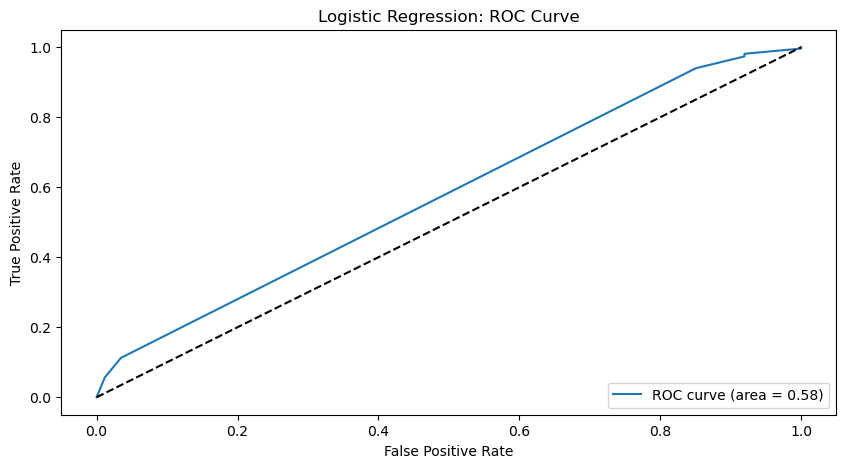

In [13]:
# Predict the test data with a threshold of 0.5
y_pred_logistic = (log_model.predict_proba(X_test_logistic)[:, 1] >= 0.5).astype(int)

# Calculate accuracy rate, sensitivity, and specificity
accuracy = (y_pred_logistic == y_test_logistic).mean()
conf_matrix = confusion_matrix(y_test_logistic, y_pred_logistic)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f'Accuracy: {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

# Define the type of error to minimize and evaluate classifier performance
# In this context, we might want to minimize false negatives (Type II error) to ensure we correctly identify third-person games
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(y_test_logistic, y_pred_logistic))

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test_logistic, log_model.predict_proba(X_test_logistic)[:, 1])
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: ROC Curve')
plt.legend(loc="lower right")
plt.show()

# 4. Conclusion
Summarize the findings from the linear and logistic regression analyses.

- Linear Summary: In the linear regression analysis, we explored the relationship between the total sales of video games (US Sales in millions) and the game's review score, after controlling for the release year and platform. The model explained approximately 11.04% of the variability in the response variable (US Sales in millions). The RMSE of 1.0886 indicates the average deviation of the predicted sales from the actual sales in the test data. The slope coefficient for 'Review Score' was 0.0246, suggesting that for each additional unit increase in the review score, the US sales (in millions) are expected to increase by this amount, holding all other variables constant.

- Logistic Summary: In the logistic regression analysis, we examined how platform, isometric view, and side-scrolling relate to the log-odds of a video game being classified as third-person. The logistic regression model showed that higher values of certain features are associated with a higher probability of being classified as third-person. The model's pseudo-R2 was 0.7479 and the AUC was 0.5773, indicating the strength of the model. The classifier built on this model had an accuracy rate of 0.7514, a sensitivity of 0.9963, and a specificity of 0.0000. The ROC curve further illustrated the model's performance.

- Limitations: There were several limitations in our analysis. First, the dataset only includes video games released between 2004 and 2010, which may not be representative of current trends in the video game industry. Additionally, the dataset may contain missing or inaccurate data, which could affect the results. The linear regression model assumes a linear relationship between the explanatory variables and the response variable, which may not always be the case. Similarly, the logistic regression model assumes a linear relationship between the explanatory variables and the log-odds of the response variable. These assumptions may not hold true in all cases, potentially affecting the validity of our results.

- Future Work: Future work could involve exploring more recent datasets to capture current trends in the video game industry. Additionally, incorporating more advanced modeling techniques, such as random forests or neural networks, could potentially improve the accuracy of our predictions. Further analysis could also investigate other factors that may influence video game sales and classification, such as marketing efforts, social media presence, and player demographics. Finally, conducting a more thorough data cleaning process and addressing any missing or inaccurate data could help improve the reliability of our results.